Position RMSE: 0.2986 m
Velocity RMSE: 0.7626 m/s


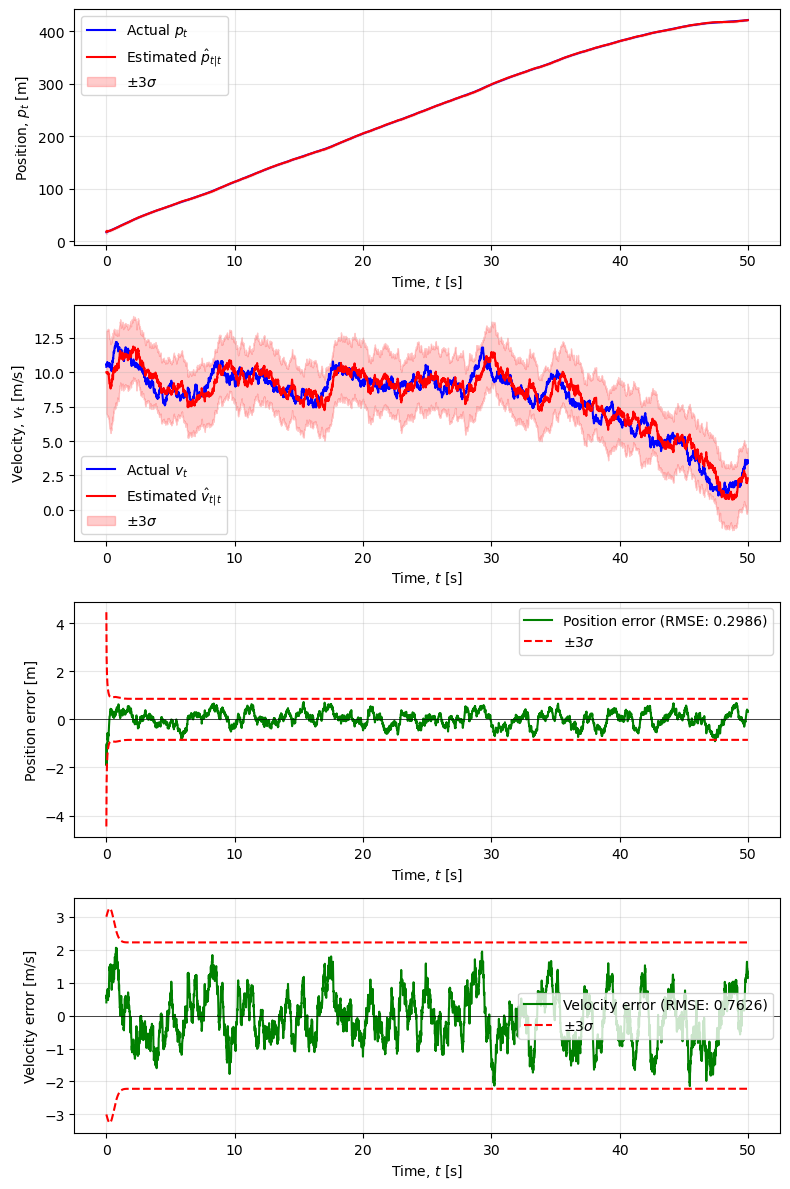

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(0)

# Problem data
h = 0.01
Q = 0.01
R = 1.5**2

A = np.array([[1, h], [0, 1]])
G = np.array([[0], [1]])
C = np.array([[1, 0]])

x0_tilde = np.array([[0], [10]])
P0 = np.array([[100, 0], [0, 1]])

# Measurement and Time update functions
def measurement_update(sigma_tu, x_tu, y):
    z = C @ sigma_tu @ C.T + R  # auxiliary variable
    x_mu = x_tu + sigma_tu @ C.T @ np.linalg.solve(z, y - C@x_tu)
    sigma_mu = sigma_tu - sigma_tu @ C.T @ np.linalg.solve(z, C@sigma_tu)
    return sigma_mu, x_mu

def time_update(sigma_mu, x_mu):
    x_tu = A @ x_mu
    sigma_tu = A @ sigma_mu @ A.T + Q * (G @ G.T)
    return sigma_tu, x_tu

# Implementation of KF
n_sim = 5000
x = np.random.multivariate_normal(x0_tilde.flatten(), P0, 1).reshape((-1,1))  # random initial state
sigma_tu, x_tu = P0, x0_tilde.reshape((-1, 1))  # initialisation

x_cache = np.zeros((n_sim, 2))
x_mu_cache = np.zeros((n_sim-1, 2))
sigma_mu_cache = np.zeros((n_sim-1, 2, 2))
x_cache[0, :] = x.T

for t in range(n_sim - 1):
    v = np.random.normal(0, np.sqrt(R), 1)
    y = C @ x + v
    sigma_mu, x_mu = measurement_update(sigma_tu, x_tu, y)
    x_mu_cache[t, :] = x_mu.T
    sigma_mu_cache[t] = sigma_mu
    sigma_tu, x_tu = time_update(sigma_mu, x_mu)
    w = np.random.normal(0, np.sqrt(Q), 1).T
    x = A @ x + G * w
    x_cache[t+1, :] = x.T

t_axis = np.arange(n_sim) * h

sigma_p  = np.sqrt(sigma_mu_cache[:, 0, 0])  # position std
sigma_vv = np.sqrt(sigma_mu_cache[:, 1, 1])  # velocity std

# Plot configuration using subplots
fig, axs = plt.subplots(4, 1, figsize=(8, 12))

# Plot 1: Position
axs[0].plot(t_axis, x_cache[:, 0], 'b-', label='Actual $p_t$')
axs[0].plot(t_axis[:-1], x_mu_cache[:, 0], 'r-', label=r'Estimated $\hat{p}_{t|t}$')
axs[0].fill_between(t_axis[:-1], x_mu_cache[:, 0] - 3*sigma_p,
                    x_mu_cache[:, 0] + 3*sigma_p, alpha=0.2, color='red', label=r'$\pm 3\sigma$')
axs[0].set_xlabel('Time, $t$ [s]')
axs[0].set_ylabel('Position, $p_t$ [m]')
axs[0].legend()
axs[0].grid(True, alpha=0.3)

# Plot 2: Velocity
axs[1].plot(t_axis, x_cache[:, 1], 'b-', label='Actual $v_t$')
axs[1].plot(t_axis[:-1], x_mu_cache[:, 1], 'r-', label=r'Estimated $\hat{v}_{t|t}$')
axs[1].fill_between(t_axis[:-1], x_mu_cache[:, 1] - 3*sigma_vv,
                    x_mu_cache[:, 1] + 3*sigma_vv, alpha=0.2, color='red', label=r'$\pm 3\sigma$')
axs[1].set_xlabel('Time, $t$ [s]')
axs[1].set_ylabel('Velocity, $v_t$ [m/s]')
axs[1].legend()
axs[1].grid(True, alpha=0.3)

# Plot 3: Position error 
axs[2].plot(t_axis[:-1], x_cache[:-1, 0] - x_mu_cache[:, 0], 'g-', label=f'Position error (RMSE: {rmse_p:.4f})')
axs[2].plot(t_axis[:-1],  3*sigma_p, 'r--', label=r'$\pm 3\sigma$')
axs[2].plot(t_axis[:-1], -3*sigma_p, 'r--')
axs[2].axhline(0, color='k', linewidth=0.5)
axs[2].set_xlabel('Time, $t$ [s]')
axs[2].set_ylabel('Position error [m]')
axs[2].legend()
axs[2].grid(True, alpha=0.3)

# Plot 4: Velocity error 
axs[3].plot(t_axis[:-1], x_cache[:-1, 1] - x_mu_cache[:, 1], 'g-', label=f'Velocity error (RMSE: {rmse_v:.4f})')
axs[3].plot(t_axis[:-1],  3*sigma_vv, 'r--', label=r'$\pm 3\sigma$')
axs[3].plot(t_axis[:-1], -3*sigma_vv, 'r--')
axs[3].axhline(0, color='k', linewidth=0.5)
axs[3].set_xlabel('Time, $t$ [s]')
axs[3].set_ylabel('Velocity error [m/s]')
axs[3].legend()
axs[3].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()